# Homework #3
## Introduction to deep learning


This colaboratory contains Homework #3 which is due **March 1 midnight (23:59 EET time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.

**NB! Links to your colaboratory will not be accepted as a solution!**
## Submission's rules:

1.   Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in one IPYNB file.


##List of Homework's exercises:

1.   [Ex1](#scrollTo=4YtaQwccjrAL) - 4 points
2.   [Ex2](#scrollTo=tOfgGIUtIizt) - 4 points
3.   [Ex3](#scrollTo=rt6Fuo28nQkd) - 2 points
4.   [Bonus 1](#scrollTo=wT-4aQqUtDU7) - 2 points
5.   [Bonus 2](#scrollTo=lEW4oyQhnRQA) - 2 points


In [ ]:
# A bit of setup
import numpy as np
import matplotlib.pyplot as plt

Here we will define few functions that will help us visualise classifiers that we are going to build in this class. Don't worry if you don't understand this code completely.

In [ ]:
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython

# for very shallow models
def plot_classifier(X, y, W, b):
  st = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, st),
                       np.arange(y_min, y_max, st))
  Z = np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b
  Z = np.argmax(Z, axis=1)
  Z = Z.reshape(xx.shape)
  fig = plt.figure()
  plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors = 'white', cmap=plt.cm.Spectral)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

# for two-layer network
def plot_neural_network(X, y, W,b ,W2, b2):
  st = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, st),
                       np.arange(y_min, y_max, st))
  Z = np.dot(np.maximum(0, np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b), W2) + b2
  Z = np.argmax(Z, axis=1)
  Z = Z.reshape(xx.shape)
  fig = plt.figure()
  plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors = 'white', cmap=plt.cm.Spectral)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

In [ ]:
N = 100 # number of points per class
D = 2 # number of features (dimensions)
K = 2 # number of classes (purple and red circles)
X = np.zeros((N*K,D)) # data matrix (each row = single example)
num_examples = X.shape[0]
y = np.zeros((N*K, 1), dtype='int') # class labels

In [ ]:
# Creating spiral data points
np.random.seed(1111)

for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix, 0] = j

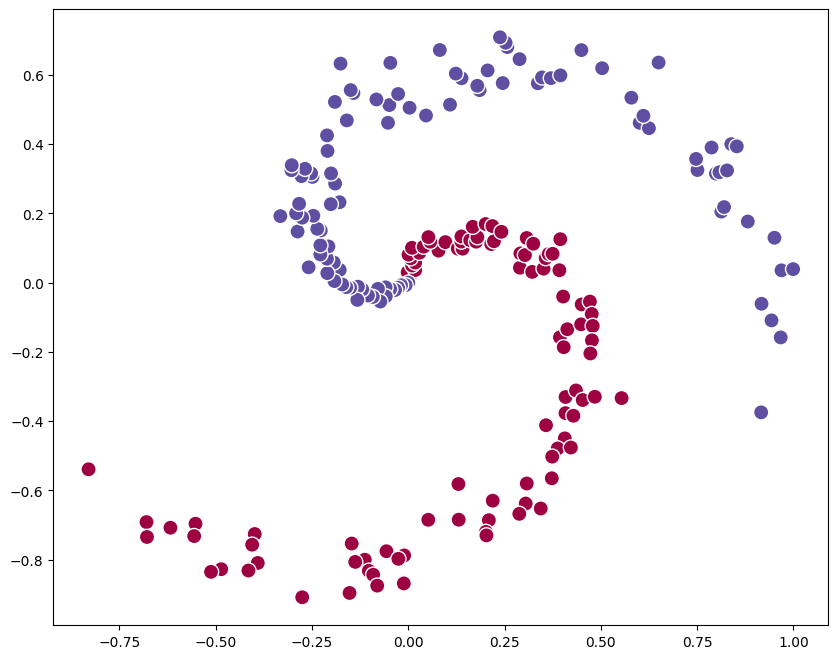

In [ ]:
# this is matplotlib...
plt.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors = 'white', cmap=plt.cm.Spectral)
plt.show()

For our implementation we would need to transform the vector of correct labels `y` into one hot encoded matrix, let's call it `truth`. Сreating `truth` as one-hot encoded labels (`y`)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore')
truth = enc.fit_transform(y).toarray()

# first column is for red
# second is for purple class

## Homework exercise 1 (4 points): three-layer network
 <font color='red'>In the class we have obtained ~94% using 2-layer neural network when classifying points in spiral. This is surely not good enough for us. Hence, let's make a few tweaks in attempt to reach higher performance.</font>

<font color='red'>**PS: Before you start working on this task, please read it in its entirety!**</font>

<font color='red'> **(a)** Based on the code we have written in the practice session, build a new 3-layer neural network, consiting two hidden layers (each of size `h`) and one output layer. Use `tanh` as an activation function for the hidden layers. Compute both feedforward and backpropagation paths to update the model weights and produce predictions. Answer a question at the end of this subtask. **(1.5 points)**. </font>

In [ ]:
num_examples = X.shape[0]

# Initialize parameters randomly
h = 100  # Size of hidden layer
W = np.random.randn(D,h)
b = np.zeros((1,h))
W2 = np.random.randn(h,h)
b2 = np.zeros((1,h))
W3 = np.random.randn(h,K)
b3 = np.zeros((1,K))

# Some hyperparameters
step_size = 1e-0

# Gradient descent loop
##### YOUR CODE STARTS #####
for i in range(2000):

  # Forward path
  hidden_layer = np.tanh(X @ W + b)
  hidden_layer_2 = np.tanh(hidden_layer @ W2 + b2)
  answers = hidden_layer_2 @ W3 + b3

  # Compute the error: average sum of squared differences
  total_error = 0.5 * np.sum((truth - answers) ** 2)
  total_error = total_error / len(X)

  if i % 100 == 0:
    print("iteration %d: loss %e" % (i, total_error))

  # Compute the gradient on answers
  dTEdA = -truth + answers
  dTEdA /= len(X)

  # Backpropagate the gradient to the parameters
  # First backprop into parameters W3 and b3
  dW3 = hidden_layer_2.T @ dTEdA
  db3 = np.sum(dTEdA, axis = 0)

  # Backprop into hidden layer 2
  dH2 = dTEdA @ W3.T

  # Then backprop into W2 and b2
  dW2 = hidden_layer.T @ (dH2 * (1 - np.tanh(hidden_layer @ W2 + b2) ** 2))
  db2 = db2 = np.sum(dH2 * (1 - np.tanh(hidden_layer @ W2 + b2) ** 2), axis = 0)

  # Backprop into hidden layer
  dH = (dH2 * (1 - hidden_layer_2 ** 2)) @ W2.T

  # Finally into W,b
  dW = X.T @ (dH * (1 - hidden_layer ** 2))
  db = np.sum(dH * (1 - hidden_layer ** 2), axis = 0)

  # Perform a parameter update
  W += -step_size * dW
  b += -step_size * db
  W2 += -step_size * dW2
  b2 += -step_size * db2
  W3 += -step_size * dW3
  b3 += -step_size * db3
  ##### YOUR CODE ENDS #####

iteration 0: loss 9.743016e+01


/tmp/ipykernel_1262/4100653372.py:25: RuntimeWarning: overflow encountered in square
  total_error = 0.5 * np.sum((truth - answers) ** 2)
/tmp/ipykernel_1262/4100653372.py:41: RuntimeWarning: overflow encountered in matmul
  dH2 = dTEdA @ W3.T
/tmp/ipykernel_1262/4100653372.py:44: RuntimeWarning: invalid value encountered in multiply
  dW2 = hidden_layer.T @ (dH2 * (1 - np.tanh(hidden_layer @ W2 + b2) ** 2))
/tmp/ipykernel_1262/4100653372.py:45: RuntimeWarning: invalid value encountered in multiply
  db2 = db2 = np.sum(dH2 * (1 - np.tanh(hidden_layer @ W2 + b2) ** 2), axis = 0)
/tmp/ipykernel_1262/4100653372.py:48: RuntimeWarning: invalid value encountered in multiply
  dH = (dH2 * (1 - hidden_layer_2 ** 2)) @ W2.T


iteration 100: loss nan
iteration 200: loss nan
iteration 300: loss nan
iteration 400: loss nan


KeyboardInterrupt: 

<font color='red'> If you have implemented everything correctly, you should have encountered a problem :)
Below name the problem and describe why it happens: </font>

<font color='red'> Your answer: </font> Large step size.

<font color='red'> **(b)** Fix the issue you have encountered above using one of the ideas that we have discussed in the lecture. Please, insert and run the updated code in the cell below. **(1.5 points)**. </font>

In [ ]:
##### YOUR CODE STARTS #####
num_examples = X.shape[0]

# Initialize parameters randomly
h = 100  # Size of hidden layer
W = np.random.randn(D,h)
b = np.zeros((1,h))
W2 = np.random.randn(h,h)
b2 = np.zeros((1,h))
W3 = np.random.randn(h,K)
b3 = np.zeros((1,K))

# Some hyperparameters
step_size = 1e-3

# Gradient descent loop
##### YOUR CODE STARTS #####
for i in range(2000):

  # Forward path
  hidden_layer = np.tanh(X @ W + b)
  hidden_layer_2 = np.tanh(hidden_layer @ W2 + b2)
  answers = hidden_layer_2 @ W3 + b3

  # Compute the error: average sum of squared differences
  total_error = 0.5 * np.sum((truth - answers) ** 2)
  total_error = total_error / len(X)

  if i % 100 == 0:
    print("iteration %d: loss %e" % (i, total_error))

  # Compute the gradient on answers
  dTEdA = -truth + answers
  dTEdA /= len(X)

  # Backpropagate the gradient to the parameters
  # First backprop into parameters W3 and b3
  dW3 = hidden_layer_2.T @ dTEdA
  db3 = np.sum(dTEdA, axis = 0)

  # Backprop into hidden layer 2
  dH2 = dTEdA @ W3.T

  # Then backprop into W2 and b2
  dW2 = hidden_layer.T @ (dH2 * (1 - np.tanh(hidden_layer @ W2 + b2) ** 2))
  db2 = np.sum(dH2 * (1 - np.tanh(hidden_layer @ W2 + b2) ** 2), axis = 0)

  # Backprop into hidden layer
  dH = (dH2 * (1 - hidden_layer_2 ** 2)) @ W2.T

  # Finally into W,b
  dW = X.T @ (dH * (1 - hidden_layer ** 2))
  db = np.sum(dH * (1 - hidden_layer ** 2), axis = 0)

  # Perform a parameter update
  W += -step_size * dW
  b += -step_size * db
  W2 += -step_size * dW2
  b2 += -step_size * db2
  W3 += -step_size * dW3
  b3 += -step_size * db3
##### YOUR CODE ENDS #####

iteration 0: loss 3.396115e+01
iteration 100: loss 5.412008e-01
iteration 200: loss 2.828780e-01
iteration 300: loss 2.001377e-01
iteration 400: loss 1.596166e-01
iteration 500: loss 1.356689e-01
iteration 600: loss 1.193933e-01
iteration 700: loss 1.070771e-01
iteration 800: loss 9.705039e-02
iteration 900: loss 8.850945e-02
iteration 1000: loss 8.107244e-02
iteration 1100: loss 7.457669e-02
iteration 1200: loss 6.894033e-02
iteration 1300: loss 6.408095e-02
iteration 1400: loss 5.989917e-02
iteration 1500: loss 5.629251e-02
iteration 1600: loss 5.316823e-02
iteration 1700: loss 5.044772e-02
iteration 1800: loss 4.806602e-02
iteration 1900: loss 4.596970e-02


<font color='red'> If it worked fine, evaluate your model running the code below. </font>

In [ ]:
#evaluate training set accuracy
hidden_layer = np.tanh(np.dot(X, W) + b)
hidden_layer_2 = np.tanh(np.dot(hidden_layer, W2) + b2) # NB, tanh activation
answers = np.dot(hidden_layer_2, W3) + b3 # Note, no activation function for the last layer!
predicted_class = np.argmax(answers, axis=1)
print('training accuracy: %.2f' % (np.mean(predicted_class == y[:,0])))

training accuracy: 0.99


<font color='red'> You should get about 98% of accuracy or more... </font>



<font color='red'> **(c)** Update function `plot_deep_neural_network` by altering the code of `plot_neural_network` to visualise obtained 3-layer network with `tanh` activation function. Visualise obtained decision boundary. How did it change comparing to the one we have observed by 2-layer models? Do you think you would be able to easily get 100% for this data? **(1 point)** </font>



In [ ]:
def plot_deep_neural_network(X, y, W, b ,W2, b2, W3, b3):
  h = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                       np.arange(y_min, y_max, h))

  ##### YOUR CODE STARTS #####
  Z = np.dot(np.tanh(np.dot(np.tanh(np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b), W2) + b2), W3) + b3
  ##### YOUR CODE ENDS #####

  Z = np.argmax(Z, axis=1)
  Z = Z.reshape(xx.shape)
  fig = plt.figure()
  plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors = 'white', cmap=plt.cm.Spectral)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

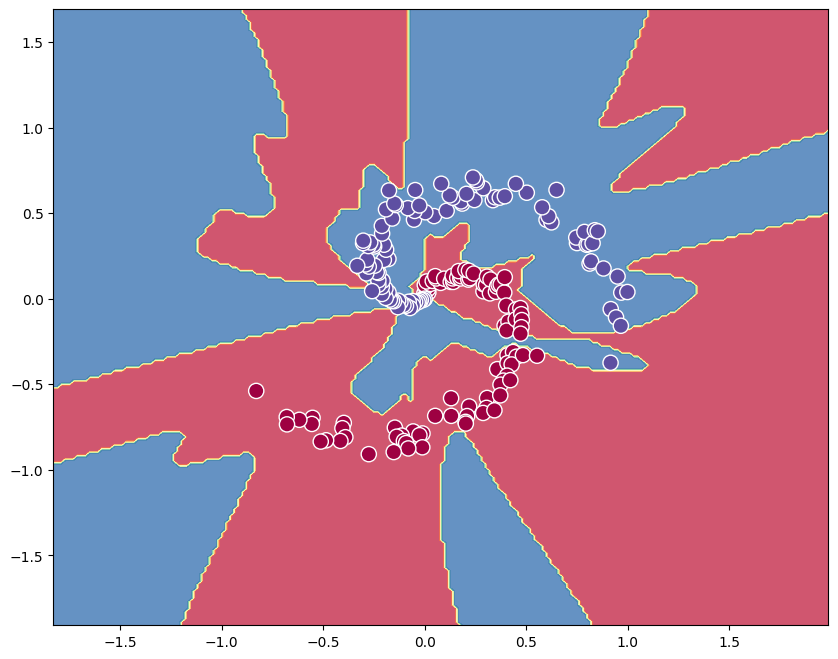

In [ ]:
# plot the resulting classifier
plot_deep_neural_network(X, y, W, b, W2, b2, W3, b3)

<font color='red'> Answer to **(c)**: </font> If compare 2-layer and 3-layer model, we can see that second one decision boundary become much more complex. The model becomes more expressive and can represent more complicated functions. But also its look like overfitting



## Homework exercise 2 (4 points): exploring neural network parameters
<font color='red'> When using neural networks it is very important to be familiar with different layers and how these layers affect the overall performance of the model. As we have already seen in the class, neural network layers consist of weights and biases.  </font>


In [ ]:
# A bit of setup again
from tensorflow.keras.datasets import cifar10

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, MaxPooling2D, BatchNormalization, Dropout

# Keras comes with built-in loaders for common datasets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# shorten dataset for quicker training
X_train = X_train[:25000]
y_train = y_train[:25000]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step
Train data shape:  (25000, 32, 32, 3)
Train labels shape:  (25000, 1)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)


In [ ]:
mu = X_train.mean(axis=(0,1,2)) # finds mean of R, G and B separately
std = X_train.std(axis=(0,1,2)) # same for std
X_train_norm = (X_train - mu)/std
X_test_norm = (X_test - mu)/std


<font color='red'> **(a)** Copy paste below the initial CNN model created for CIFAR10. Then update it so that the total number of parameters in the updated model is exactly 364406. You can alter any architectural aspects of the model. Take your time to study how changes in different parameters impact the number of overall weights. Here, you only have to change **one type** of parameters to gain the required total number of weights. Finally, train the model, visualise the learning curves and evaluate it on the test set (**1.5 points**). </font>

In [ ]:
##### YOUR CODE STARTS #####
x = Input(shape=(32, 32, 3))
c1 = Conv2D(16, (3, 3), strides=(1, 1), padding="same")(x)
b1 = BatchNormalization()(c1)
a1 = Activation('relu')(b1)
c2 = Conv2D(16, (3, 3), strides=(1, 1), padding="valid")(a1)
b2 = BatchNormalization()(c2)
a2 = Activation('relu')(b2)
p2 = MaxPooling2D(pool_size=2)(a2)
d2 = Dropout(rate=0.25)(p2)
f2 = Flatten()(d2) # tensor into vector
h3 = Dense(100)(f2)
b3 = BatchNormalization()(h3)
a3 = Activation('relu')(b3)
d3 = Dropout(rate=0.5)(a3)
z = Dense(10)(d3)
p = Activation('softmax')(z)
##### YOUR CODE ENDS #####

In [ ]:
smaller_model = Model(inputs=x, outputs=p)
smaller_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
smaller_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 30, 30, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       360,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 364,406 (1.39 MB)

 Trainable params: 364,142 (1.39 MB)

 Non-trainable params: 264 (1.03 KB)

In [ ]:
# Fit the model; returns History object
history_smaller = smaller_model.fit(X_train_norm, y_train, batch_size=64, epochs=20, validation_split=0.1)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.3956 - loss: 1.7272 - val_accuracy: 0.5352 - val_loss: 1.2990
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5227 - loss: 1.3483 - val_accuracy: 0.5632 - val_loss: 1.2486
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5685 - loss: 1.2201 - val_accuracy: 0.6180 - val_loss: 1.0982
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6039 - loss: 1.1230 - val_accuracy: 0.6140 - val_loss: 1.0925
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6244 - loss: 1.0643 - val_accuracy: 0.6240 - val_loss: 1.0611
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6415 - loss: 1.0173 - val_accuracy: 0.6588 - val_loss: 0.9999
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6565 - loss: 0.9716 - val_accuracy: 0.6496 - val_loss: 1.0116
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6677 - loss: 0.9348 - val_accuracy: 

Text(0.5, 1.0, 'Accuracy')

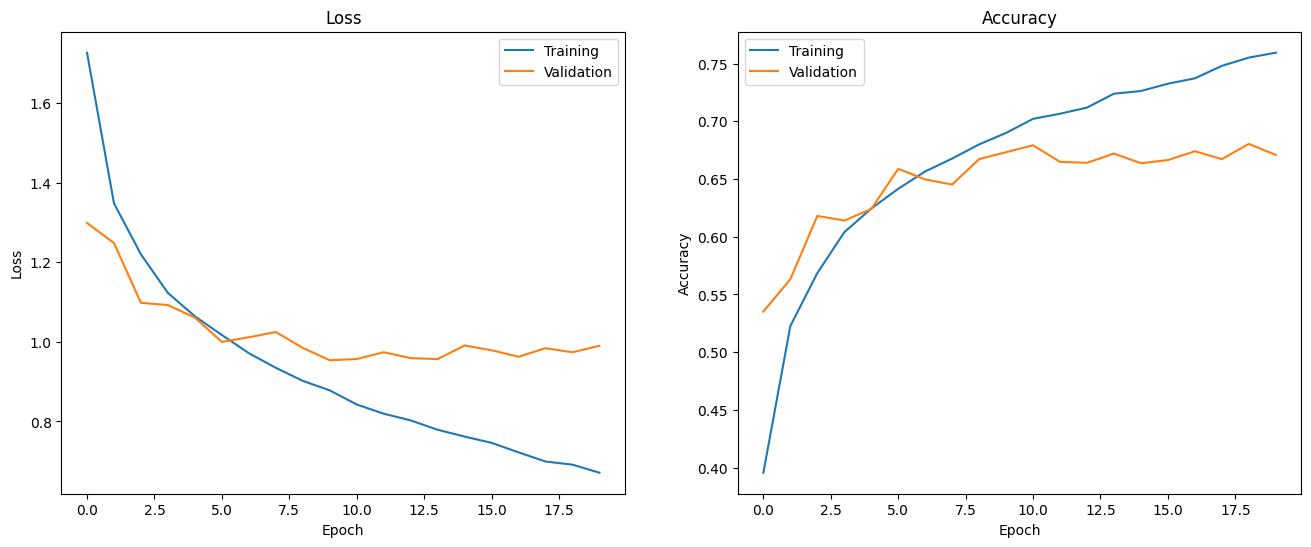

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history_smaller.history['loss'])
plt.plot(history_smaller.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history_smaller.history['accuracy'])
plt.plot(history_smaller.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training', 'Validation'])
plt.title('Accuracy')

In [ ]:
#evaluate the model on test set
##### YOUR CODE STARTS #####
res = smaller_model.predict(X_test_norm)

res_right = np.argmax(res, axis = 1)

accuracy = np.mean(y_test.flatten() == res_right)

print(accuracy)

##### YOUR CODE ENDS #####

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
0.6646


<font color='red'> **(b)** Now modify the initial CNN model so that the total number of parameters is exactly 1480742. As in the previous subtask, you can change any architectural aspects of the model. Take your time to study how changes in different parameters impact the number of overall weights. Here, you only have to change **one type** of parameters to gain the required total number of weights. Finally, train the model, visualise the learning curves and evaluate it on the test set (**1.5 points**). </font>

In [ ]:
##### YOUR CODE STARTS #####

x = Input(shape=(32, 32, 3))
c1 = Conv2D(64, (3, 3), strides=(1, 1), padding="same")(x)
b1 = BatchNormalization()(c1)
a1 = Activation('relu')(b1)
c2 = Conv2D(64, (3, 3), strides=(1, 1), padding="valid")(a1)
b2 = BatchNormalization()(c2)
a2 = Activation('relu')(b2)
p2 = MaxPooling2D(pool_size=2)(a2)
d2 = Dropout(rate=0.25)(p2)
f2 = Flatten()(d2) # tensor into vector
h3 = Dense(100)(f2)
b3 = BatchNormalization()(h3)
a3 = Activation('relu')(b3)
d3 = Dropout(rate=0.5)(a3)
z = Dense(10)(d3)
p = Activation('softmax')(z)

##### YOUR CODE ENDS #####

In [ ]:
bigger_model = Model(inputs=x, outputs=p)
bigger_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
bigger_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │     1,440,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,480,742 (5.65 MB)

 Trainable params: 1,480,286 (5.65 MB)

 Non-trainable params: 456 (1.78 KB)

In [ ]:
# Fit the model; returns History object
history_bigger = bigger_model.fit(X_train_norm, y_train, batch_size=64, epochs=20, validation_split=0.1)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4358 - loss: 1.6098 - val_accuracy: 0.5340 - val_loss: 1.3784
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5789 - loss: 1.1976 - val_accuracy: 0.6240 - val_loss: 1.0984
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6347 - loss: 1.0401 - val_accuracy: 0.6500 - val_loss: 0.9992
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6675 - loss: 0.9490 - val_accuracy: 0.6768 - val_loss: 0.9126
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6954 - loss: 0.8722 - val_accuracy: 0.6784 - val_loss: 0.9252
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7188 - loss: 0.7943 - val_accuracy: 0.6748 - val_loss: 0.9509
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7389 - loss: 0.7378 - val_accuracy: 0.6760 - val_loss: 0.9436
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7584 - loss: 0.6845 - val_accuracy: 

Text(0.5, 1.0, 'Accuracy')

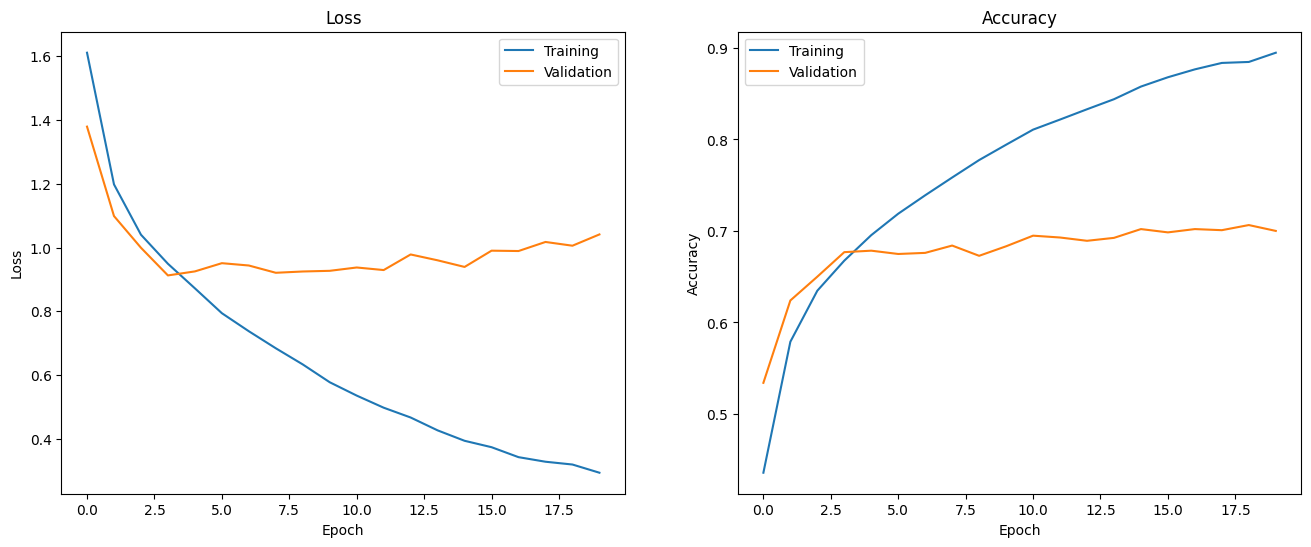

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history_bigger.history['loss'])
plt.plot(history_bigger.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history_bigger.history['accuracy'])
plt.plot(history_bigger.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training', 'Validation'])
plt.title('Accuracy')

In [ ]:
#evaluate the model on test set
##### YOUR CODE STARTS #####
res = bigger_model.predict(X_test_norm)

res_right = np.argmax(res, axis = 1)

accuracy = np.mean(y_test.flatten() == res_right)

print(accuracy)
##### YOUR CODE ENDS #####

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
0.6897


<font color='red'> **(c)** Compare learning curves for smaller and bigger versions and say which version has overfitted the data? Why do you think so? Which network you would run in production? (**1 point**). </font>

<font color='red'>  Answer to **(c)**: </font> The second model is overfitted because we can see that the training loss is much smaller than the validation loss. This means that the model has adapted too much to the training data. In production, I would use the smaller model for a couple of reasons. First, it gives approximately the same result as the bigger model, and second, it uses much less computational power.

## Homework exercise 3 (2 points): Create your own dataset and build a CNN model using Torch API
<font color='red'> In this exercise, you have a chance to test if CNN can distinguish between images of your favourite objects. </font>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

<font color='red'> **(a)** Create your own dataset with two or more classes. Dataset should be created manually by collecting images for two classes
(e.g., cats and dogs) and organizing them into:

data/train/class_name  
data/valid/class_name  

Each class contains multiple images downloaded from the internet. **(1 point)** </font>

In [ ]:
##### YOUR CODE STARTS #####
from google.colab import files
uploaded = files.upload()
##### YOUR CODE ENDS #####

KeyboardInterrupt: 

In [ ]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Image transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Assume folder structure:
# data/
#    train/
#        class1/
#        class2/
#    valid/
#        class1/
#        class2/

train_dataset = datasets.ImageFolder("data/train", transform=transform)
valid_dataset = datasets.ImageFolder("data/valid", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)

Using device: cpu
Classes: ['class1', 'class2']


In [ ]:
# add more cells as necessary

<font color='red'> **(b)** train a neural network on images you have acquired **(0.5 points)** </font>

In [ ]:
##### YOUR CODE STARTS #####
class SimpleCIFARCNN_4conv(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2)

        self.relu = nn.ReLU(inplace=True)
        self.drop_conv = nn.Dropout(p=0.25)

        self.flatten_dim = 32 * 32 * 32
        self.fc1 = nn.Linear(self.flatten_dim, 100)
        self.bn_fc1 = nn.BatchNorm1d(100)
        self.drop_fc = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(100, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)


        x = self.drop_conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(self.bn_fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)
        return x

model = SimpleCIFARCNN_4conv(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.7)

epochs = 100

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()


        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)
    scheduler.step()

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    history['train_loss'].append(train_loss / train_total)
    history['train_acc'].append(train_correct / train_total)
    history['val_loss'].append(val_loss / val_total)
    history['val_acc'].append(val_correct / val_total)

    print(f'Epoch {epoch+1}: Train Acc={train_correct/train_total:.3f}, Val Acc={val_correct/val_total:.3f}')


##### YOUR CODE ENDS #####

Epoch 1: Train Acc=0.458, Val Acc=0.500
Epoch 2: Train Acc=0.875, Val Acc=0.500
Epoch 3: Train Acc=1.000, Val Acc=0.500
Epoch 4: Train Acc=1.000, Val Acc=0.500
Epoch 5: Train Acc=1.000, Val Acc=0.500
Epoch 6: Train Acc=1.000, Val Acc=0.500
Epoch 7: Train Acc=1.000, Val Acc=0.500
Epoch 8: Train Acc=1.000, Val Acc=0.500
Epoch 9: Train Acc=1.000, Val Acc=0.500
Epoch 10: Train Acc=1.000, Val Acc=0.500
Epoch 11: Train Acc=1.000, Val Acc=0.500
Epoch 12: Train Acc=1.000, Val Acc=0.500
Epoch 13: Train Acc=1.000, Val Acc=0.500
Epoch 14: Train Acc=1.000, Val Acc=0.500
Epoch 15: Train Acc=1.000, Val Acc=0.500
Epoch 16: Train Acc=1.000, Val Acc=0.500
Epoch 17: Train Acc=1.000, Val Acc=0.500
Epoch 18: Train Acc=1.000, Val Acc=0.500
Epoch 19: Train Acc=1.000, Val Acc=0.500
Epoch 20: Train Acc=1.000, Val Acc=0.500
Epoch 21: Train Acc=1.000, Val Acc=0.500
Epoch 22: Train Acc=1.000, Val Acc=0.500
Epoch 23: Train Acc=1.000, Val Acc=0.500
Epoch 24: Train Acc=1.000, Val Acc=0.500
Epoch 25: Train Acc=1.000

Plot the confusion matrix to make sure that you model has learned something:

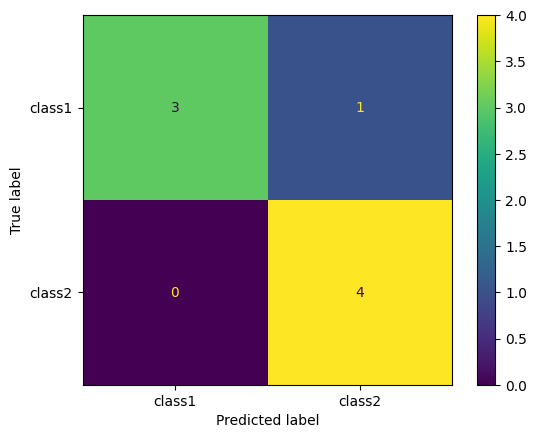

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=train_dataset.classes)
disp.plot()
plt.show()

<font color='red'> **(c)** Test your model on one or more images from the internet that represent classes you have chosen, but unlikely to be in the training data. Print out class probabilities for one of these test images. **(0.5 points)** </font>

In [ ]:
##### YOUR CODE STARTS #####
test_dataset = datasets.ImageFolder("data/test", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = test_dataset.classes

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        probs = torch.softmax(model(images), dim=1)
        preds = probs.argmax(dim=1)

        for i in range(len(images)):
            print("\nProbabilities:")
            for j in range(len(class_names)):
                print(f"{class_names[j]}: {probs[i][j].item()}")

            print("True class:", class_names[labels[i].item()])
            print("Predicted class:", class_names[preds[i].item()])
##### YOUR CODE ENDS #####


Probabilities:
class1: 0.848597526550293
class2: 0.15140247344970703
True class: class1
Predicted class: class1

Probabilities:
class1: 0.21689355373382568
class2: 0.7831064462661743
True class: class1
Predicted class: class2

Probabilities:
class1: 0.07430014759302139
class2: 0.9256998896598816
True class: class2
Predicted class: class2

Probabilities:
class1: 0.8783001899719238
class2: 0.12169979512691498
True class: class2
Predicted class: class1


In [ ]:
# What are the probabilities of different classes for this image?
##### YOUR CODE STARTS #####
...
##### YOUR CODE ENDS #####

## Bonus exercise 2 (1 bonus points):

<font color='red'> Modify the 3-layer neural network code from homework exercise 1 by replacing tanh activation functions with sigmoid. Adjust both the forward and backward propagation paths accordingly to accommodate this change.
Afterward, execute the code for the same number of iterations (epochs) as in exercise 1 and compute accuracy. Visualize the obtained classifier and interpret the results.
Did the network with sigmoid perform better or worse?
If the performance with sigmoid activations is worse than with tanh, identify the possible reasons and explain potential solutions. Implement the necessary fixes and rerun the updated code while keeping the original architecture of the neural network (three layers with hidden layers using sigmoid activation function). Your objective is to achieve the same performance as with tanh (0.99). </font>

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
##### YOUR CODE STARTS #####
num_examples = X.shape[0]

# Initialize parameters randomly
h = 100  # Size of hidden layer
W = np.random.randn(D,h)
b = np.zeros((1,h))
W2 = np.random.randn(h,h)
b2 = np.zeros((1,h))
W3 = np.random.randn(h,K)
b3 = np.zeros((1,K))

# Some hyperparameters
step_size = 1e-3

# Gradient descent loop
##### YOUR CODE STARTS #####
for i in range(2000):

  # Forward path
  hidden_layer = sigmoid(X @ W + b)
  hidden_layer_2 = sigmoid(hidden_layer @ W2 + b2)
  answers = hidden_layer_2 @ W3 + b3

  # Compute the error: average sum of squared differences
  total_error = 0.5 * np.sum((truth - answers) ** 2)
  total_error = total_error / len(X)

  if i % 100 == 0:
    print("iteration %d: loss %e" % (i, total_error))

  # Compute the gradient on answers
  dTEdA = -truth + answers
  dTEdA /= len(X)

  # Backpropagate the gradient to the parameters
  # First backprop into parameters W3 and b3
  dW3 = hidden_layer_2.T @ dTEdA
  db3 = np.sum(dTEdA, axis = 0)

  # Backprop into hidden layer 2
  dH2 = dTEdA @ W3.T

  # Then backprop into W2 and b2
  dW2 = hidden_layer.T @ (dH2 * (sigmoid(hidden_layer @ W2 + b2)*(1-sigmoid(hidden_layer @ W2 + b2))))
  db2 = np.sum(dH2 * (sigmoid(hidden_layer @ W2 + b2)*(1-sigmoid(hidden_layer @ W2 + b2))), axis = 0)

  # Backprop into hidden layer
  dH = (dH2 * (1 - hidden_layer_2 ** 2)) @ W2.T

  # Finally into W,b
  dW = X.T @ (dH * (1 - hidden_layer ** 2))
  db = np.sum(dH * (1 - hidden_layer ** 2), axis = 0)

  # Perform a parameter update
  W += -step_size * dW
  b += -step_size * db
  W2 += -step_size * dW2
  b2 += -step_size * db2
  W3 += -step_size * dW3
  b3 += -step_size * db3
##### YOUR CODE ENDS #####

iteration 0: loss 8.252422e+00
iteration 100: loss 6.693600e-01
iteration 200: loss 5.119064e-01
iteration 300: loss 4.082387e-01
iteration 400: loss 3.232212e-01
iteration 500: loss 2.504673e-01
iteration 600: loss 1.937418e-01
iteration 700: loss 1.547092e-01
iteration 800: loss 1.293268e-01
iteration 900: loss 1.124965e-01
iteration 1000: loss 1.006856e-01
iteration 1100: loss 9.183486e-02
iteration 1200: loss 8.479198e-02
iteration 1300: loss 7.892417e-02
iteration 1400: loss 7.389324e-02
iteration 1500: loss 6.952120e-02
iteration 1600: loss 6.570880e-02
iteration 1700: loss 6.238931e-02
iteration 1800: loss 5.950602e-02
iteration 1900: loss 5.700422e-02


In [ ]:
hidden_layer = sigmoid(np.dot(X, W) + b)
hidden_layer_2 = sigmoid(np.dot(hidden_layer, W2) + b2) # NB, tanh activation
answers = np.dot(hidden_layer_2, W3) + b3 # Note, no activation function for the last layer!
predicted_class = np.argmax(answers, axis=1)
print('training accuracy: %.2f' % (np.mean(predicted_class == y[:,0])))

training accuracy: 0.97


# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the homework, possibly answering the following questions:
* how much time did you spend on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us

Your comments:

# <font color='red'>  End of the homework. Please don't delete this cell.</font>